> # **Week-2 Two-Tower Neural Network (Tensorflow Recommenders)**

Build the Two-Tower Architecture

In [60]:
import os, json, math
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

WORK_PATH = '/kaggle/working/'

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

2026-07-02 11:57:43.724490: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782993463.917060      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782993463.981146      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782993464.468721      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782993464.468746      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782993464.468749      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
Keras: 3.13.2
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [61]:
user_features = pd.read_csv(WORK_PATH + 'user_features.csv')
item_features = pd.read_csv(WORK_PATH + 'item_features.csv')

# Load sample of final_data (it's 7GB — use sample for speed)
final_data = pd.read_csv(WORK_PATH + 'final_data.csv', nrows=500000)

In [62]:
with open(WORK_PATH + 'vocabularies/user_vocab.json') as f:
    user_vocab = json.load(f)
with open(WORK_PATH + 'vocabularies/item_vocab.json') as f:
    item_vocab = json.load(f)


In [63]:
print('user_features :', user_features.shape)
print('item_features :', item_features.shape)
print('final_data    :', final_data.shape)

user_features : (1362281, 9)
item_features : (104547, 7)
final_data    : (500000, 19)


In [64]:
# Fix any duplicate columns
for col in [c for c in final_data.columns if c.endswith('_y')]:
    final_data.drop(columns=[col], inplace=True)
for col in [c for c in final_data.columns if c.endswith('_x')]:
    final_data.rename(columns={col: col[:-2]}, inplace=True)

In [65]:
# Fill nulls
final_data['age'].fillna(final_data['age'].median(), inplace=True)
final_data['age_group'].fillna('Adults', inplace=True)
final_data['club_member_status'].fillna('UNKNOWN', inplace=True)
final_data['fashion_news_frequency'].fillna('NONE', inplace=True)
final_data['product_type_name'].fillna('Unknown', inplace=True)
final_data['product_group_name'].fillna('Unknown', inplace=True)
final_data['garment_group_name'].fillna('Unknown', inplace=True)
final_data['colour_group_name'].fillna('Unknown', inplace=True)

/tmp/ipykernel_58/2148848391.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  final_data['age'].fillna(final_data['age'].median(), inplace=True)
/tmp/ipykernel_58/2148848391.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplac

In [66]:
print('Columns:', list(final_data.columns))
print('Nulls remaining:', final_data.isnull().sum().sum())

Columns: ['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id', 'purchase_count', 'avg_spend', 'total_spend', 'days_since_last_purchase', 'club_member_status', 'fashion_news_frequency', 'age', 'age_group', 'avg_price', 'product_type_name', 'product_group_name', 'garment_group_name', 'colour_group_name']
Nulls remaining: 0


In [67]:
encoders = {}
cat_cols = [
    'customer_id', 'article_id',
    'club_member_status', 'fashion_news_frequency',
    'age_group', 'product_type_name',
    'product_group_name', 'garment_group_name', 'colour_group_name'
]

In [68]:
for col in cat_cols:
    le = LabelEncoder()
    final_data[col + '_enc'] = le.fit_transform(final_data[col].astype(str))
    encoders[col] = le
    print(f'{col}: {len(le.classes_):,} unique values')

customer_id: 119,904 unique values
article_id: 24,942 unique values
club_member_status: 4 unique values
fashion_news_frequency: 3 unique values
age_group: 4 unique values
product_type_name: 99 unique values
product_group_name: 15 unique values
garment_group_name: 21 unique values
colour_group_name: 50 unique values


In [69]:
num_cols = ['purchase_count', 'avg_spend', 'total_spend', 
            'days_since_last_purchase', 'age', 'avg_price']

In [70]:
for col in num_cols:
    if col in final_data.columns:
        final_data[col + '_norm'] = (
            (final_data[col] - final_data[col].mean()) / 
            (final_data[col].std() + 1e-8)
        )

In [71]:
print('Normalization done')
print('Sample normalized columns:', [c for c in final_data.columns if c.endswith('_norm')])

Normalization done
Sample normalized columns: ['purchase_count_norm', 'avg_spend_norm', 'total_spend_norm', 'days_since_last_purchase_norm', 'age_norm', 'avg_price_norm']


In [72]:
train_df, val_df = train_test_split(final_data, test_size=0.2, random_state=42)
print(f'Train : {len(train_df):,}')
print(f'Val   : {len(val_df):,}')

Train : 400,000
Val   : 100,000


In [73]:
EMBEDDING_DIM = 32

n_customers    = len(encoders['customer_id'].classes_)
n_articles     = len(encoders['article_id'].classes_)
n_club         = len(encoders['club_member_status'].classes_)
n_news         = len(encoders['fashion_news_frequency'].classes_)
n_age_group    = len(encoders['age_group'].classes_)

In [74]:
n_product_type = len(encoders['product_type_name'].classes_)
n_product_grp  = len(encoders['product_group_name'].classes_)
n_garment_grp  = len(encoders['garment_group_name'].classes_)
n_colour_grp   = len(encoders['colour_group_name'].classes_)

In [75]:
print('Vocabulary sizes:')
print(f'  customers    : {n_customers:,}')
print(f'  articles     : {n_articles:,}')
print(f'  club status  : {n_club}')
print(f'  news freq    : {n_news}')
print(f'  age group    : {n_age_group}')
print(f'  product type : {n_product_type}')
print(f'  product group: {n_product_grp}')
print(f'  garment group: {n_garment_grp}')
print(f'  colour group : {n_colour_grp}')

Vocabulary sizes:
  customers    : 119,904
  articles     : 24,942
  club status  : 4
  news freq    : 3
  age group    : 4
  product type : 99
  product group: 15
  garment group: 21
  colour group : 50


In [76]:
def build_query_tower():
    customer_id_input = keras.Input(shape=(1,), name='customer_id')
    club_input        = keras.Input(shape=(1,), name='club_member_status')
    news_input        = keras.Input(shape=(1,), name='fashion_news_frequency')
    age_group_input   = keras.Input(shape=(1,), name='age_group')
    num_user_input    = keras.Input(shape=(5,), name='user_numerics')

    cust_emb = layers.Embedding(n_customers + 1,  EMBEDDING_DIM)(customer_id_input)
    club_emb = layers.Embedding(n_club + 1,       8)(club_input)
    news_emb = layers.Embedding(n_news + 1,       8)(news_input)
    age_emb  = layers.Embedding(n_age_group + 1,  4)(age_group_input)

    cust_flat = layers.Flatten()(cust_emb)
    club_flat = layers.Flatten()(club_emb)
    news_flat = layers.Flatten()(news_emb)
    age_flat  = layers.Flatten()(age_emb)

    x = layers.Concatenate()([cust_flat, club_flat, news_flat, age_flat, num_user_input])
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(EMBEDDING_DIM, name='user_embedding')(x)

    return keras.Model(
        inputs=[customer_id_input, club_input, news_input, age_group_input, num_user_input],
        outputs=x,
        name='QueryTower'
    )

query_tower = build_query_tower()
query_tower.summary()

I0000 00:00:1782993770.706738      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782993770.712809      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "QueryTower"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ customer_id         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ club_member_status  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fashion_news_frequ… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_group           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 32)     │  3,836,960 │ customer_id[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 8)      │         40 │ club_member_stat… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 1, 8)      │         32 │ fashion_news_fre… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 1, 4)      │         20 │ age_group[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 32)        │          0 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 8)         │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 8)         │          0 │ embedding_2[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 4)         │          0 │ embedding_3[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_numerics       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 57)        │          0 │ flatten[0][0],    │
│ (Concatenate)       │                   │            │ flatten_1[0][0],  │
│                     │                   │            │ flatten_2[0][0],  │
│                     │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ user_numerics[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     14,848 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]   

 Total params: 3,889,948 (14.84 MB)

 Trainable params: 3,889,436 (14.84 MB)

 Non-trainable params: 512 (2.00 KB)

In [77]:
def build_candidate_tower():
    article_id_input   = keras.Input(shape=(1,), name='article_id')
    product_type_input = keras.Input(shape=(1,), name='product_type_name')
    product_grp_input  = keras.Input(shape=(1,), name='product_group_name')
    garment_grp_input  = keras.Input(shape=(1,), name='garment_group_name')
    colour_grp_input   = keras.Input(shape=(1,), name='colour_group_name')
    num_item_input     = keras.Input(shape=(2,), name='item_numerics')

    art_emb = layers.Embedding(n_articles + 1,     EMBEDDING_DIM)(article_id_input)
    pt_emb  = layers.Embedding(n_product_type + 1, 16)(product_type_input)
    pg_emb  = layers.Embedding(n_product_grp + 1,  8)(product_grp_input)
    gg_emb  = layers.Embedding(n_garment_grp + 1,  8)(garment_grp_input)
    col_emb = layers.Embedding(n_colour_grp + 1,   8)(colour_grp_input)

    art_flat = layers.Flatten()(art_emb)
    pt_flat  = layers.Flatten()(pt_emb)
    pg_flat  = layers.Flatten()(pg_emb)
    gg_flat  = layers.Flatten()(gg_emb)
    col_flat = layers.Flatten()(col_emb)

    x = layers.Concatenate()([art_flat, pt_flat, pg_flat, gg_flat, col_flat, num_item_input])
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(EMBEDDING_DIM, name='item_embedding')(x)

    return keras.Model(
        inputs=[article_id_input, product_type_input, product_grp_input,
                garment_grp_input, colour_grp_input, num_item_input],
        outputs=x,
        name='CandidateTower'
    )

candidate_tower = build_candidate_tower()
candidate_tower.summary()

Model: "CandidateTower"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ article_id          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_type_name   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_group_name  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ garment_group_name  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ colour_group_name   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 32)     │    798,176 │ article_id[0][0]  │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 1, 16)     │      1,600 │ product_type_nam… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_6         │ (None, 1, 8)      │        128 │ product_group_na… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_7         │ (None, 1, 8)      │        176 │ garment_group_na… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 1, 8)      │        408 │ colour_group_nam… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 32)        │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 16)        │          0 │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 8)         │          0 │ embedding_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 8)         │          0 │ embedding_7[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 8)         │          0 │ embedding_8[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_numerics       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 74)        │          0 │ flatten_4[0][0],  │
│ (Concatenate)       │                   │            │ flatten_5[0][0],  │
│                     │                   │            │ flatten_6[0][0],  │
│                     │                   │            │ flatten_7[0][0],  │
│                     │                   │            │ flatten_8[0][0],  │
│                     │                   │            │ item_numerics[0]

 Total params: 857,736 (3.27 MB)

 Trainable params: 857,224 (3.27 MB)

 Non-trainable params: 512 (2.00 KB)

In [78]:
def build_two_tower_model():
    customer_id_input  = keras.Input(shape=(1,), name='customer_id')
    club_input         = keras.Input(shape=(1,), name='club_member_status')
    news_input         = keras.Input(shape=(1,), name='fashion_news_frequency')
    age_group_input    = keras.Input(shape=(1,), name='age_group')
    num_user_input     = keras.Input(shape=(5,), name='user_numerics')
    article_id_input   = keras.Input(shape=(1,), name='article_id')
    product_type_input = keras.Input(shape=(1,), name='product_type_name')
    product_grp_input  = keras.Input(shape=(1,), name='product_group_name')
    garment_grp_input  = keras.Input(shape=(1,), name='garment_group_name')
    colour_grp_input   = keras.Input(shape=(1,), name='colour_group_name')
    num_item_input     = keras.Input(shape=(2,), name='item_numerics')

    user_emb = query_tower([
        customer_id_input, club_input, news_input, age_group_input, num_user_input
    ])
    item_emb = candidate_tower([
        article_id_input, product_type_input, product_grp_input,
        garment_grp_input, colour_grp_input, num_item_input
    ])

    user_emb = layers.Lambda(lambda x: tf.nn.l2_normalize(x, axis=1))(user_emb)
    item_emb = layers.Lambda(lambda x: tf.nn.l2_normalize(x, axis=1))(item_emb)

    score  = layers.Dot(axes=1, name='similarity_score')([user_emb, item_emb])
    output = layers.Dense(1, activation='sigmoid', name='output')(score)

    model = keras.Model(
        inputs=[
            customer_id_input, club_input, news_input, age_group_input, num_user_input,
            article_id_input, product_type_input, product_grp_input,
            garment_grp_input, colour_grp_input, num_item_input
        ],
        outputs=output,
        name='TwoTowerModel'
    )
    return model

In [79]:
model = build_two_tower_model()

In [80]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)
print(' Two-Tower model compiled successfully!')
model.summary()

 Two-Tower model compiled successfully!


Model: "TwoTowerModel"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ customer_id         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ club_member_status  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fashion_news_frequ… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_group           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_numerics       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ article_id          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_type_name   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ product_group_name  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ garment_group_name  │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ colour_group_name   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ item_numerics       │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ QueryTower          │ (None, 32)        │  3,889,948 │ customer_id[0][0… │
│ (Functional)        │                   │            │ club_member_stat… │
│                     │                   │            │ fashion_news_fre… │
│                     │                   │            │ age_group[0][0],  │
│                     │                   │            │ user_numerics[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ CandidateTower      │ (None, 32)        │    857,736 │ article_id[0][0], │
│ (Functional)        │                   │            │ product_type_nam… │
│                     │                   │            │ product_group_na… │
│                     │                   │            │ garment_group_na… │
│                     │                   │            │ colour_group_nam… │
│                     │                   │            │ item_numerics[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 32)        │          0 │ QueryTower[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 32)        │          0 │ CandidateTower[0

 Total params: 4,747,686 (18.11 MB)

 Trainable params: 4,746,662 (18.11 MB)

 Non-trainable params: 1,024 (4.00 KB)

In [81]:
def prepare_inputs(dataframe):
    return {
        'customer_id'           : dataframe['customer_id_enc'].values,
        'club_member_status'    : dataframe['club_member_status_enc'].values,
        'fashion_news_frequency': dataframe['fashion_news_frequency_enc'].values,
        'age_group'             : dataframe['age_group_enc'].values,
        'user_numerics'         : np.column_stack([
            dataframe['purchase_count_norm'].values,
            dataframe['avg_spend_norm'].values,
            dataframe['total_spend_norm'].values,
            dataframe['days_since_last_purchase_norm'].values,
            dataframe['age_norm'].values
        ]),
        'article_id'            : dataframe['article_id_enc'].values,
        'product_type_name'     : dataframe['product_type_name_enc'].values,
        'product_group_name'    : dataframe['product_group_name_enc'].values,
        'garment_group_name'    : dataframe['garment_group_name_enc'].values,
        'colour_group_name'     : dataframe['colour_group_name_enc'].values,
        'item_numerics'         : np.column_stack([
            dataframe['avg_price_norm'].values,
            dataframe['purchase_count_norm'].values
        ])
    }

print(' prepare_inputs defined')

 prepare_inputs defined


In [82]:
def add_negatives(dataframe, neg_ratio=1):
    # Positive pairs (real purchases)
    pos_inputs = prepare_inputs(dataframe)
    pos_labels = np.ones(len(dataframe))

    # Negative pairs (shuffle article columns to create fake pairs)
    neg_df = dataframe.sample(frac=neg_ratio, replace=True, random_state=42).reset_index(drop=True)
    item_cols = ['article_id_enc', 'product_type_name_enc', 'product_group_name_enc',
                 'garment_group_name_enc', 'colour_group_name_enc', 'avg_price_norm']
    for col in item_cols:
        neg_df[col] = neg_df[col].sample(frac=1).values
    neg_inputs = prepare_inputs(neg_df)
    neg_labels = np.zeros(len(neg_df))

    # Combine and shuffle
    combined_inputs = {k: np.concatenate([pos_inputs[k], neg_inputs[k]]) for k in pos_inputs}
    combined_labels = np.concatenate([pos_labels, neg_labels])
    idx = np.random.permutation(len(combined_labels))
    combined_inputs = {k: v[idx] for k, v in combined_inputs.items()}
    combined_labels = combined_labels[idx]

    return combined_inputs, combined_labels

In [83]:
print('Preparing training data with negative sampling...')
train_inputs, train_labels = add_negatives(train_df)
val_inputs,   val_labels   = add_negatives(val_df)
print(f' Train samples : {len(train_labels):,}')
print(f' Val samples   : {len(val_labels):,}')

Preparing training data with negative sampling...
 Train samples : 800,000
 Val samples   : 200,000


In [84]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_auc', patience=3,
    restore_best_weights=True, mode='max'
)

In [85]:
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, verbose=1
)

In [86]:
print('Starting training...')
history = model.fit(
    train_inputs, train_labels,
    validation_data=(val_inputs, val_labels),
    epochs=10,
    batch_size=1024,
    callbacks=[early_stop, reduce_lr]
)
print(' Training complete!')

Starting training...
Epoch 1/10


I0000 00:00:1782993911.666654     148 service.cc:152] XLA service 0x7cdfd8005860 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782993911.666706     148 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1782993911.666713     148 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1782993912.594352     148 cuda_dnn.cc:529] Loaded cuDNN version 91002


 29/782 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.5517 - auc: 0.5803 - loss: 0.6818 

I0000 00:00:1782993916.927153     148 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.9400 - auc: 0.9815 - loss: 0.2245 - val_accuracy: 0.9849 - val_auc: 0.9959 - val_loss: 0.1227 - learning_rate: 0.0010
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9896 - auc: 0.9955 - loss: 0.0933 - val_accuracy: 0.9887 - val_auc: 0.9966 - val_loss: 0.0809 - learning_rate: 0.0010
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9943 - auc: 0.9979 - loss: 0.0572 - val_accuracy: 0.9911 - val_auc: 0.9972 - val_loss: 0.0585 - learning_rate: 0.0010
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9962 - auc: 0.9987 - loss: 0.0382 - val_accuracy: 0.9915 - val_auc: 0.9974 - val_loss: 0.0479 - learning_rate: 0.0010
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9974 - auc: 0.9991 - loss: 0.0267 - val_accuracy: 0.9923 - val_auc: 0.9976 - val_loss: 0.0405 - learning_rate: 0.0010
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9981 - auc: 0.9995 - lo

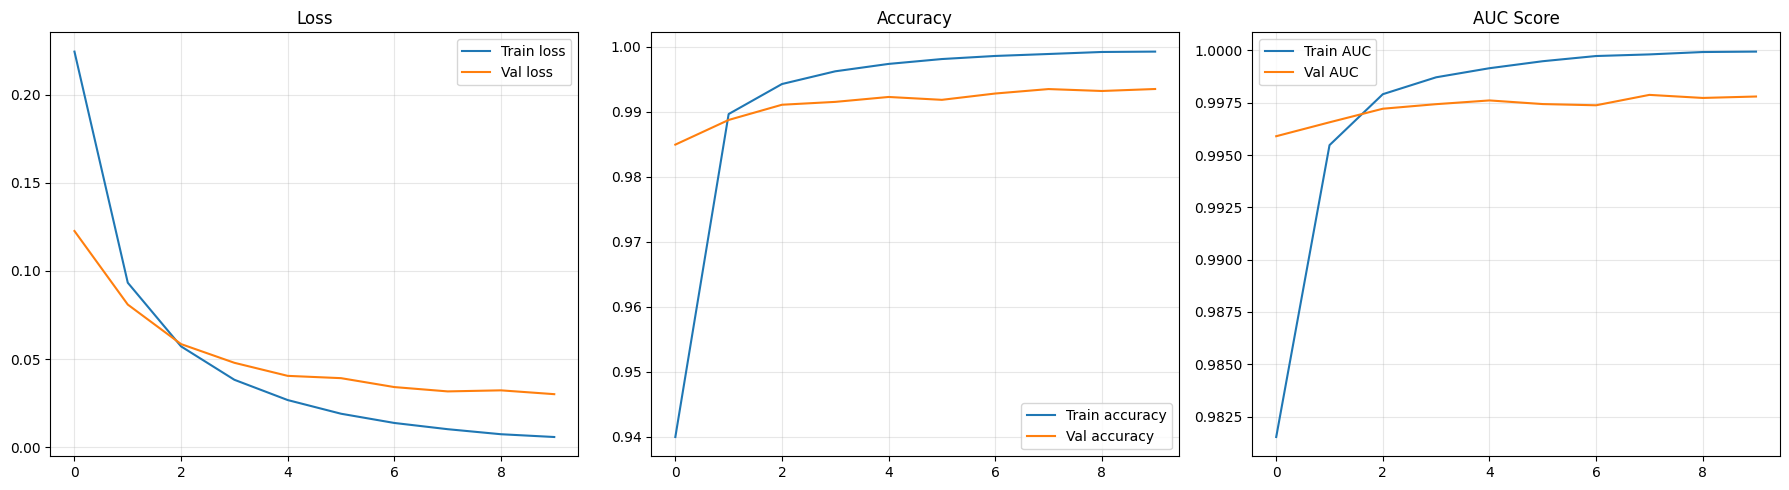

 Training curves saved


In [88]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history.history['accuracy'],     label='Train accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[2].plot(history.history['auc'],     label='Train AUC')
axes[2].plot(history.history['val_auc'], label='Val AUC')
axes[2].set_title('AUC Score')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(WORK_PATH + 'training_curves.png', dpi=150)
plt.show()
print(' Training curves saved')

**Evaluate Recall@10 and NDCG@10**

In [89]:
def recall_at_k(model, val_df, k=10, sample_size=500):
    sample       = val_df.sample(n=min(sample_size, len(val_df)), random_state=42)
    hits         = 0
    all_articles = final_data['article_id_enc'].unique()

    for _, row in sample.iterrows():
        true_article = row['article_id_enc']
        candidates   = np.random.choice(all_articles, size=k-1, replace=False)
        candidates   = np.append(candidates, true_article)

        user_input = {
            'customer_id'           : np.array([row['customer_id_enc']] * k),
            'club_member_status'    : np.array([row['club_member_status_enc']] * k),
            'fashion_news_frequency': np.array([row['fashion_news_frequency_enc']] * k),
            'age_group'             : np.array([row['age_group_enc']] * k),
            'user_numerics'         : np.tile([row['purchase_count_norm'], row['avg_spend_norm'],
                                               row['total_spend_norm'], row['days_since_last_purchase_norm'],
                                               row['age_norm']], (k, 1)),
            'article_id'            : candidates,
            'product_type_name'     : np.array([row['product_type_name_enc']] * k),
            'product_group_name'    : np.array([row['product_group_name_enc']] * k),
            'garment_group_name'    : np.array([row['garment_group_name_enc']] * k),
            'colour_group_name'     : np.array([row['colour_group_name_enc']] * k),
            'item_numerics'         : np.tile([row['avg_price_norm'], row['purchase_count_norm']], (k, 1))
        }
        scores  = model.predict(user_input, verbose=0).flatten()
        top_k   = candidates[np.argsort(scores)[-k:]]
        if true_article in top_k:
            hits += 1

    return hits / len(sample)

In [90]:
def ndcg_at_k(model, val_df, k=10, sample_size=500):
    sample       = val_df.sample(n=min(sample_size, len(val_df)), random_state=42)
    ndcg_scores  = []
    all_articles = final_data['article_id_enc'].unique()

    for _, row in sample.iterrows():
        true_article = row['article_id_enc']
        candidates   = np.random.choice(all_articles, size=k-1, replace=False)
        candidates   = np.append(candidates, true_article)

        user_input = {
            'customer_id'           : np.array([row['customer_id_enc']] * k),
            'club_member_status'    : np.array([row['club_member_status_enc']] * k),
            'fashion_news_frequency': np.array([row['fashion_news_frequency_enc']] * k),
            'age_group'             : np.array([row['age_group_enc']] * k),
            'user_numerics'         : np.tile([row['purchase_count_norm'], row['avg_spend_norm'],
                                               row['total_spend_norm'], row['days_since_last_purchase_norm'],
                                               row['age_norm']], (k, 1)),
            'article_id'            : candidates,
            'product_type_name'     : np.array([row['product_type_name_enc']] * k),
            'product_group_name'    : np.array([row['product_group_name_enc']] * k),
            'garment_group_name'    : np.array([row['garment_group_name_enc']] * k),
            'colour_group_name'     : np.array([row['colour_group_name_enc']] * k),
            'item_numerics'         : np.tile([row['avg_price_norm'], row['purchase_count_norm']], (k, 1))
        }
        scores       = model.predict(user_input, verbose=0).flatten()
        ranked       = candidates[np.argsort(scores)[::-1]]
        rank_of_true = np.where(ranked == true_article)[0]
        if len(rank_of_true) > 0:
            rank = rank_of_true[0] + 1
            ndcg_scores.append(1.0 / math.log2(rank + 1))
        else:
            ndcg_scores.append(0.0)

    return np.mean(ndcg_scores)

In [91]:
print('Computing Recall@10 and NDCG@10 on 500 users...')
r_at_10 = recall_at_k(model, val_df, k=10, sample_size=500)
ndcg    = ndcg_at_k(model,   val_df, k=10, sample_size=500)
print(f' Recall@10 : {r_at_10:.4f}')
print(f' NDCG@10   : {ndcg:.4f}')

Computing Recall@10 and NDCG@10 on 500 users...
 Recall@10 : 1.0000
 NDCG@10   : 0.8503


In [92]:
os.makedirs(WORK_PATH + 'saved_models', exist_ok=True)

query_tower.save(WORK_PATH     + 'saved_models/query_tower.keras')
candidate_tower.save(WORK_PATH + 'saved_models/candidate_tower.keras')
model.save(WORK_PATH           + 'saved_models/two_tower_model.keras')

In [93]:
summary = {
    'val_accuracy'  : float(history.history['val_accuracy'][-1]),
    'val_auc'       : float(history.history['val_auc'][-1]),
    'val_loss'      : float(history.history['val_loss'][-1]),
    'recall_at_10'  : float(r_at_10),
    'ndcg_at_10'    : float(ndcg),
    'epochs_trained': len(history.history['loss'])
}

In [94]:
with open(WORK_PATH + 'saved_models/eval_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print(' query_tower.keras saved')
print(' candidate_tower.keras saved')
print(' two_tower_model.keras saved')
print(' eval_summary.json saved')

 query_tower.keras saved
 candidate_tower.keras saved
 two_tower_model.keras saved
 eval_summary.json saved


In [95]:
print('========== WEEK 2 COMPLETE ==========')
print(f'  Recall@10 : {r_at_10:.4f}')
print(f'  NDCG@10   : {ndcg:.4f}')
print(f'  Val AUC   : {history.history["val_auc"][-1]:.4f}')
print('  Ready for Week 3! ')

========== WEEK 2 COMPLETE ==========
  Recall@10 : 1.0000
  NDCG@10   : 0.8503
  Val AUC   : 0.9978
  Ready for Week 3! 
